# Imports

In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parent # Sobe um nível para a raiz

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Raiz do projeto adicionada: {project_root}")

import lightning as L
import matplotlib.pyplot as plt
import torch
from torchmetrics import Accuracy

from minerva.data.readers.csv_reader import CSVReader
from minerva.data.datasets.base import SimpleDataset
from minerva.data.data_modules.base import MinervaDataModule
from minerva.models.nets.time_series.resnet import ResNetSE1D_5
from minerva.transforms import Reshape, CastTo, TransformPipeline

Raiz do projeto adicionada: /home/miguel/fed-har


# 1. Data Preparation

Para realizar o download do dataset você deve rodar os seguintes comandos em seu terminal:

```bash
wget https://zenodo.org/records/13987073/files/standardized_view.zip?download=1 -O daghar_standardized_view.zip
mkdir -p datasets/DAGHAR
unzip -o daghar_standardized_view.zip -d datasets/DAGHAR/
rm daghar_standardized_view.zip
```

## 1.1 Creating Data Readers and Datasets

In [2]:
# train_reader
root_data_dir = Path("/home/miguel/fed-har/datasets/DAGHAR/standardized_view/MotionSense")

# Train data and label readers
train_data_reader = CSVReader(
    path=root_data_dir / "train.csv",
    columns_to_select=["accel-x-*", "accel-y-*", "accel-z-*", "gyro-x-*", "gyro-y-*", "gyro-z-*"],
)
train_label_reader = CSVReader(
    path=root_data_dir / "train.csv",
    columns_to_select="standard activity code",
    cast_to="int64",
)

# Validation data and label readers
validation_data_reader = CSVReader(
    path=root_data_dir / "validation.csv",
    columns_to_select=["accel-x-*", "accel-y-*", "accel-z-*", "gyro-x-*", "gyro-y-*", "gyro-z-*"],
)
validation_label_reader = CSVReader(
    path=root_data_dir / "validation.csv",
    columns_to_select="standard activity code",
    cast_to="int64",
)

# Test data and label readers
test_data_reader = CSVReader(
    path=root_data_dir / "test.csv",
    columns_to_select=["accel-x-*", "accel-y-*", "accel-z-*", "gyro-x-*", "gyro-y-*", "gyro-z-*"],
)
test_label_reader = CSVReader(
    path=root_data_dir / "test.csv",
    columns_to_select="standard activity code",
    cast_to="int64",
)

print(f"Train data reader length: {len(train_data_reader)}; Label reader length: {len(train_label_reader)}")
print(f"Validation data reader length: {len(validation_data_reader)}; Label reader length: {len(validation_label_reader)}")
print(f"Test data reader length: {len(test_data_reader)}; Label reader length: {len(test_label_reader)}")

Train data reader length: 3558; Label reader length: 3558
Validation data reader length: 420; Label reader length: 420
Test data reader length: 1062; Label reader length: 1062


In [3]:
train_dataset = SimpleDataset(
    readers=[
        train_data_reader,  # Reader for the data
        train_label_reader  # Reader for the labels
    ],
    transforms=[
        TransformPipeline([Reshape((6, 60)), CastTo("float32")]),   # Transforms to apply to the data
        CastTo("int64")                                             # Cast the labels to int64
    ]
)

val_dataset = SimpleDataset(
    readers=[
        validation_data_reader,
        validation_label_reader
    ],
    transforms=[
        TransformPipeline([Reshape((6, 60)), CastTo("float32")]),   # Transforms to apply to the data
        CastTo("int64")                                             # Cast the labels to int64
    ]
)

test_dataset = SimpleDataset(
    readers=[test_data_reader, test_label_reader],
    transforms=[
        TransformPipeline([Reshape((6, 60)), CastTo("float32")]),   # Transforms to apply to the data
        CastTo("int64")                                             # Cast the labels to int64
    ]
)

In [4]:
print(f"Train dataset\n {train_dataset}\n")
print(f"Validation dataset\n {val_dataset}\n")
print(f"Test dataset\n {test_dataset}\n")

Train dataset
           📂 SimpleDataset Information            
📌 Dataset Type: SimpleDataset
   └── Reader 0: TabularReader(df=(3558, 728), columns_to_select=['accel-x-*', 'accel-y-*', 'accel-z-*', 'gyro-x-*', 'gyro-y-*', 'gyro-z-*'], cast_to=None, data_shape=None)
   │     └── Transform: TransformPipeline(transforms=[Reshape(shape=(6, 60)), CastTo(dtype=float32)])
   └── Reader 1: TabularReader(df=(3558, 728), columns_to_select=['standard activity code'], cast_to=int64, data_shape=None)
   │     └── Transform: CastTo(dtype=int64)
   │
   └── Total Readers: 2

Validation dataset
           📂 SimpleDataset Information            
📌 Dataset Type: SimpleDataset
   └── Reader 0: TabularReader(df=(420, 728), columns_to_select=['accel-x-*', 'accel-y-*', 'accel-z-*', 'gyro-x-*', 'gyro-y-*', 'gyro-z-*'], cast_to=None, data_shape=None)
   │     └── Transform: TransformPipeline(transforms=[Reshape(shape=(6, 60)), CastTo(dtype=float32)])
   └── Reader 1: TabularReader(df=(420, 728), columns_to_

The shape of the input is (6, 60) and the label is 5


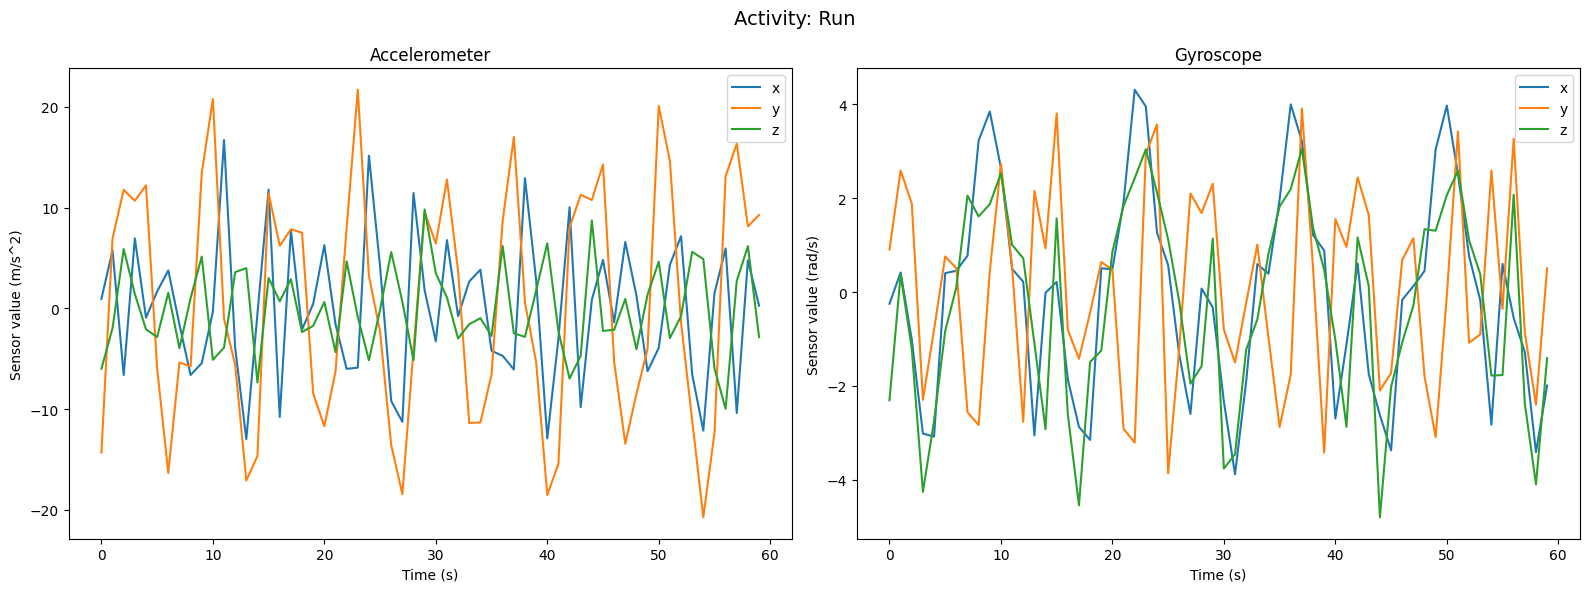

In [5]:
sample_X, sample_y = train_dataset[800]
print(f"The shape of the input is {sample_X.shape} and the label is {sample_y}")

activity_labels = {
    0: "Sit",
    1: "Stand",
    2: "Walk",
    3: "Stair-up",
    4: "Stair-down",
    5: "Run",
}

activity = activity_labels[sample_y]

fig = plt.figure(figsize=(16, 6))
fig.suptitle(f"Activity: {activity}", fontsize=14)
# Accelerometer subplot
plt.subplot(1, 2, 1)
# plt.subptitle(f"Activity: {activity}")
plt.plot(sample_X[0, :], label="x")
plt.plot(sample_X[1, :], label="y")
plt.plot(sample_X[2, :], label="z")
plt.title(f"Accelerometer")
plt.xlabel("Time (s)")
plt.ylabel("Sensor value (m/s^2)")
plt.legend()

# Gyroscope subplot
plt.subplot(1, 2, 2)
plt.plot(sample_X[3, :], label="x")
plt.plot(sample_X[4, :], label="y")
plt.plot(sample_X[5, :], label="z")
plt.title(f"Gyroscope")
plt.xlabel("Time (s)")
plt.ylabel("Sensor value (rad/s)")
plt.legend()

plt.tight_layout()
plt.show()

## 1.2 Creating the ```MinervaDataModle```

In [6]:
data_module = MinervaDataModule(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=64,
    name="MotionSense Dataset",
    num_workers=4
)

print(data_module)

               🆔 MotionSense Dataset
└── Predict Split: test
📂 Datasets:
   ├── Train Dataset:
   │      ==================================================
   │                 📂 SimpleDataset Information            
   │      ==================================================
   │      📌 Dataset Type: SimpleDataset
   │         └── Reader 0: TabularReader(df=(3558, 728), columns_to_select=['accel-x-*', 'accel-y-*', 'accel-z-*', 'gyro-x-*', 'gyro-y-*', 'gyro-z-*'], cast_to=None, data_shape=None)
   │         │     └── Transform: TransformPipeline(transforms=[Reshape(shape=(6, 60)), CastTo(dtype=float32)])
   │         └── Reader 1: TabularReader(df=(3558, 728), columns_to_select=['standard activity code'], cast_to=int64, data_shape=None)
   │         │     └── Transform: CastTo(dtype=int64)
   │         │
   │         └── Total Readers: 2
   │      ==================================================
   ├── Val Dataset:
   │      ==================================================
   │   

# 2. Creating the Model

In [7]:
model = ResNetSE1D_5(
    input_shape=(6, 60),
    num_classes=6,
)
model

ResNetSE1D_5(
  (backbone): _ResNet1D(
    (conv_block): ConvolutionalBlock(
      (block): Sequential(
        (0): Conv1d(6, 64, kernel_size=(5,), stride=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (residual_blocks): Sequential(
      (0): ResNetSEBlock(
        (block): Sequential(
          (0): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=same)
          (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=same)
          (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): SqueezeAndExcitation1D(
            (block): Sequential(
              (0): Linear(in_features=64, out_features=32, bias=True)
              (1): ReLU()
   

# 3. Defining the trainer

In [8]:
trainer = L.Trainer(
    max_epochs=100,
    devices=1,
    accelerator="gpu",
    logger=False,
    enable_checkpointing=False,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## 3.1. Training the model

In [9]:
trainer.fit(model, data_module)

You are using a CUDA device ('NVIDIA GeForce MX570 A') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone │ _ResNet1D        │  126 K │ train │     0 │
│ 1 │ fc       │ Linear           │    390 │ train │     0 │
│ 2 │ loss_fn  │ CrossEntropyLoss │      0 │ train │     0 │
└───┴──────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 127 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 127 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 76                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/home/miguel/fed-har/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

/home/miguel/fed-har/.venv/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called 
`self.log('val_loss', ..., logger=True)` but have no logger configured. You can enable one by doing 
`Trainer(logger=ALogger(...))`

/home/miguel/fed-har/.venv/lib/python3.11/site-packages/lightning/pytorch/core/module.py:522: You called 
`self.log('train_loss', ..., logger=True)` but have no logger configured. You can enable one by doing 
`Trainer(logger=ALogger(...))`

`Trainer.fit` stopped: `max_epochs=100` reached.


# 4. Evaluating Model

In [10]:
# 1. Obtain predictions for the test set
predictions = trainer.predict(model, data_module)
# As predictions is a list of batches, we concatenate them along the first dimension
predictions = torch.cat(predictions, dim=0) # type: ignore

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [11]:
# 2. We an use the torch.argmax function to obtain the class with the highest probability
predicted_classes = torch.argmax(predictions, dim=1) # type: ignore
# Let's print the predicted classes
print(f"The shape of the predicted labels is {predicted_classes.shape} and dtype {predicted_classes.dtype}")

The shape of the predicted labels is torch.Size([1062]) and dtype torch.int64


In [12]:
# 3. Let's obtain the true labels
y = []

# We can use the test_dataset to obtain all the true labels
for i in range(len(data_module.test_dataset)):       # type: ignore
    sample_x, sample_y = data_module.test_dataset[i] # type: ignore
    y.append(sample_y) # type: ignore

y = torch.Tensor(y).flatten().to(torch.int64)
# Let's print the true labels
print(f"The shape of the true labels is {y.shape} and dtype {y.dtype}")

The shape of the true labels is torch.Size([1062]) and dtype torch.int64


In [13]:
# 4. Let's create the accuracy metric object and compute the accuracy
acc_metric = Accuracy(task="multiclass", num_classes=6)
score = acc_metric(predicted_classes, y)
print(f"The accuracy of the model is {score.item()*100:.2f}%")

The accuracy of the model is 63.37%
